# Fraud Detection — Exploratory Data Analysis

**Dataset:** IEEE-CIS Fraud Detection (Kaggle)  
**Rows:** ~590,000 transactions  
**Features:** 433 (transaction + identity tables)  

**Goal of this notebook:**  
Understand the data deeply enough to make informed preprocessing decisions.  
Every section ends with a `→ Preprocessing decision` note.

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../data/raw'
PROCESSED_DIR = '../data/processed'

import os
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load and merge transaction + identity tables
txn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
df  = txn.merge(idn, on='TransactionID', how='left')

print(f'Transaction table : {txn.shape}')
print(f'Identity table    : {idn.shape}')
print(f'Merged            : {df.shape}')
print(f'Fraud rate        : {df["isFraud"].mean()*100:.2f}%')

Transaction table : (590540, 394)
Identity table    : (144233, 41)
Merged            : (590540, 434)
Fraud rate        : 3.50%


---
## 2. Target Variable — Class Imbalance

In [3]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate   = df['isFraud'].mean()
ratio        = int((fraud_counts[0] / fraud_counts[1]))

print('='*45)
print(f'  Legit transactions : {fraud_counts[0]:>8,}')
print(f'  Fraud transactions : {fraud_counts[1]:>8,}')
print(f'  Fraud rate         : {fraud_rate*100:>7.2f}%')
print(f'  Class ratio        : {ratio}:1  (legit:fraud)')
print('='*45)

  Legit transactions :  569,877
  Fraud transactions :   20,663
  Fraud rate         :    3.50%
  Class ratio        : 27:1  (legit:fraud)


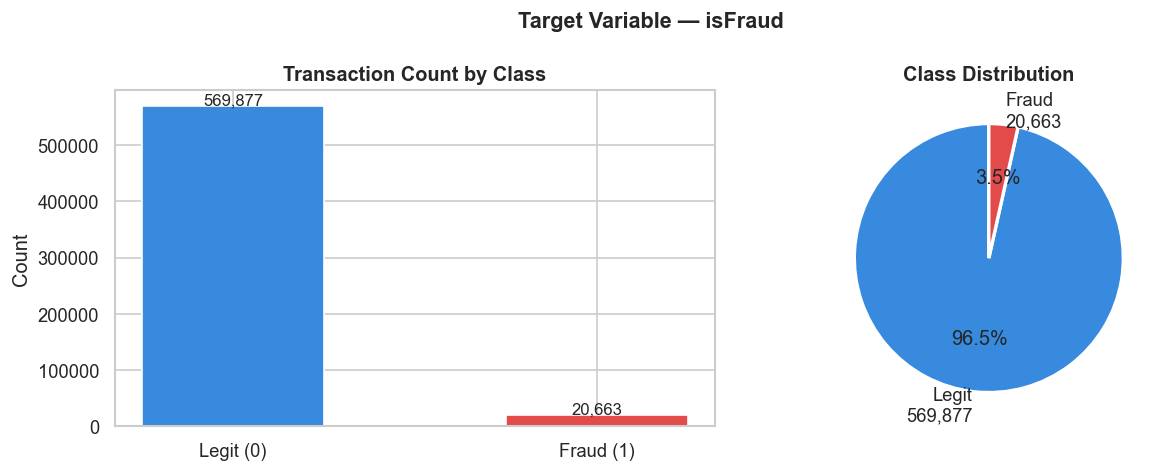

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#378ADD', '#E24B4A']
axes[0].bar(['Legit (0)', 'Fraud (1)'], fraud_counts.values, color=colors, width=0.5)
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(
    fraud_counts.values,
    labels=[f'Legit\n{fraud_counts[0]:,}', f'Fraud\n{fraud_counts[1]:,}'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution', fontweight='bold')

plt.suptitle('Target Variable — isFraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_01_class_imbalance.png', bbox_inches='tight')
plt.show()

**→ Preprocessing decision:**  
- Fraud rate is only **3.5%** — severely imbalanced (28:1 ratio)  
- AUC-ROC is misleading on imbalanced data — use **Average Precision** as primary metric  
- Set `scale_pos_weight = 28` in XGBoost to penalise missing fraud more than missing legit  
- Use **stratified train/val split** to preserve fraud ratio in both sets  
- Tune threshold with **F2-score** (beta=2) to bias toward recall — catching fraud matters more than false alarms

---
## 3. Transaction Amount

In [5]:
print('TransactionAmt statistics:')
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2).to_string())

TransactionAmt statistics:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


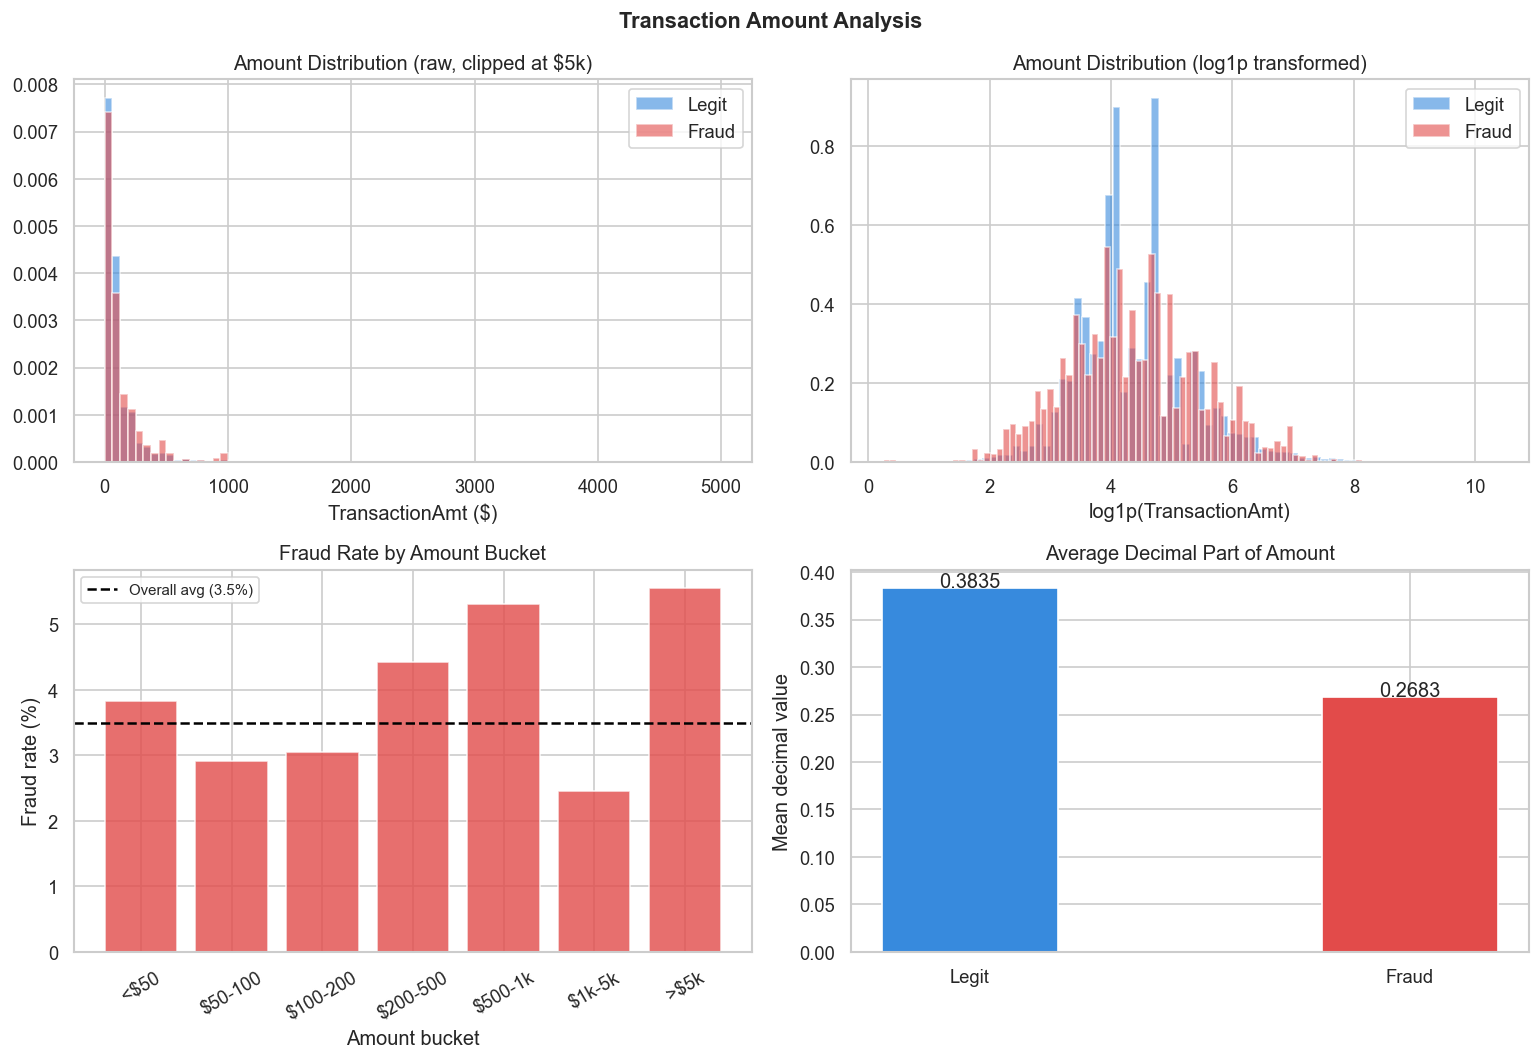

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Raw distribution (log scale)
for label, color in [(0, '#378ADD'), (1, '#E24B4A')]:
    axes[0,0].hist(
        df[df['isFraud']==label]['TransactionAmt'].clip(upper=5000),
        bins=80, alpha=0.6, color=color,
        label='Legit' if label==0 else 'Fraud',
        density=True
    )
axes[0,0].set_title('Amount Distribution (raw, clipped at $5k)')
axes[0,0].set_xlabel('TransactionAmt ($)')
axes[0,0].legend()

# log1p distribution
for label, color in [(0, '#378ADD'), (1, '#E24B4A')]:
    axes[0,1].hist(
        np.log1p(df[df['isFraud']==label]['TransactionAmt']),
        bins=80, alpha=0.6, color=color,
        label='Legit' if label==0 else 'Fraud',
        density=True
    )
axes[0,1].set_title('Amount Distribution (log1p transformed)')
axes[0,1].set_xlabel('log1p(TransactionAmt)')
axes[0,1].legend()

# Fraud rate by amount bucket
df['amt_bucket'] = pd.cut(
    df['TransactionAmt'],
    bins=[0, 50, 100, 200, 500, 1000, 5000, 99999],
    labels=['<$50','$50-100','$100-200','$200-500','$500-1k','$1k-5k','>$5k']
)
fraud_by_amt = df.groupby('amt_bucket')['isFraud'].mean() * 100
axes[1,0].bar(fraud_by_amt.index, fraud_by_amt.values, color='#E24B4A', alpha=0.8)
axes[1,0].axhline(y=fraud_rate*100, color='black', linestyle='--', label=f'Overall avg ({fraud_rate*100:.1f}%)')
axes[1,0].set_title('Fraud Rate by Amount Bucket')
axes[1,0].set_xlabel('Amount bucket')
axes[1,0].set_ylabel('Fraud rate (%)')
axes[1,0].legend(fontsize=9)
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=30)

# Decimal part of amount
df['amt_decimal'] = df['TransactionAmt'] % 1
fraud_by_decimal = df.groupby('isFraud')['amt_decimal'].mean()
axes[1,1].bar(['Legit', 'Fraud'], fraud_by_decimal.values, color=['#378ADD','#E24B4A'], width=0.4)
axes[1,1].set_title('Average Decimal Part of Amount')
axes[1,1].set_ylabel('Mean decimal value')
for i, v in enumerate(fraud_by_decimal.values):
    axes[1,1].text(i, v + 0.001, f'{v:.4f}', ha='center')

plt.suptitle('Transaction Amount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_02_transaction_amount.png', bbox_inches='tight')
plt.show()

df.drop(columns=['amt_bucket'], inplace=True)

In [7]:
# Round number analysis
df['is_round'] = (df['TransactionAmt'] % 1 == 0).astype(int)
round_fraud = df.groupby('is_round')['isFraud'].mean() * 100
print('Fraud rate by round number:')
print(f'  Non-round amounts : {round_fraud[0]:.2f}%')
print(f'  Round amounts     : {round_fraud[1]:.2f}%')
df.drop(columns=['is_round'], inplace=True)

Fraud rate by round number:
  Non-round amounts : 3.43%
  Round amounts     : 3.57%


**→ Preprocessing decision:**  
- Amount is **right-skewed** — apply `log1p` transformation for the model  
- Engineer `amt_decimal` — decimal part carries signal (fraudsters use .00 amounts more)  
- Engineer `amt_is_round` — binary flag for round dollar amounts  
- Engineer `amt_cents` — cents portion as integer feature  
- High-value transactions (>$1k) have elevated fraud rates — amount buckets not needed as XGBoost handles non-linearity

---
## 4. Time Features

In [8]:
print('TransactionDT range:')
print(f'  Min : {df["TransactionDT"].min():,} seconds')
print(f'  Max : {df["TransactionDT"].max():,} seconds')
print(f'  Span: {(df["TransactionDT"].max() - df["TransactionDT"].min()) / 86400:.0f} days')

# Engineer time features
df['hour']       = (df['TransactionDT'] // 3600) % 24
df['day_of_week']= (df['TransactionDT'] // 86400) % 7
df['is_night']   = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

TransactionDT range:
  Min : 86,400 seconds
  Max : 15,811,131 seconds
  Span: 182 days


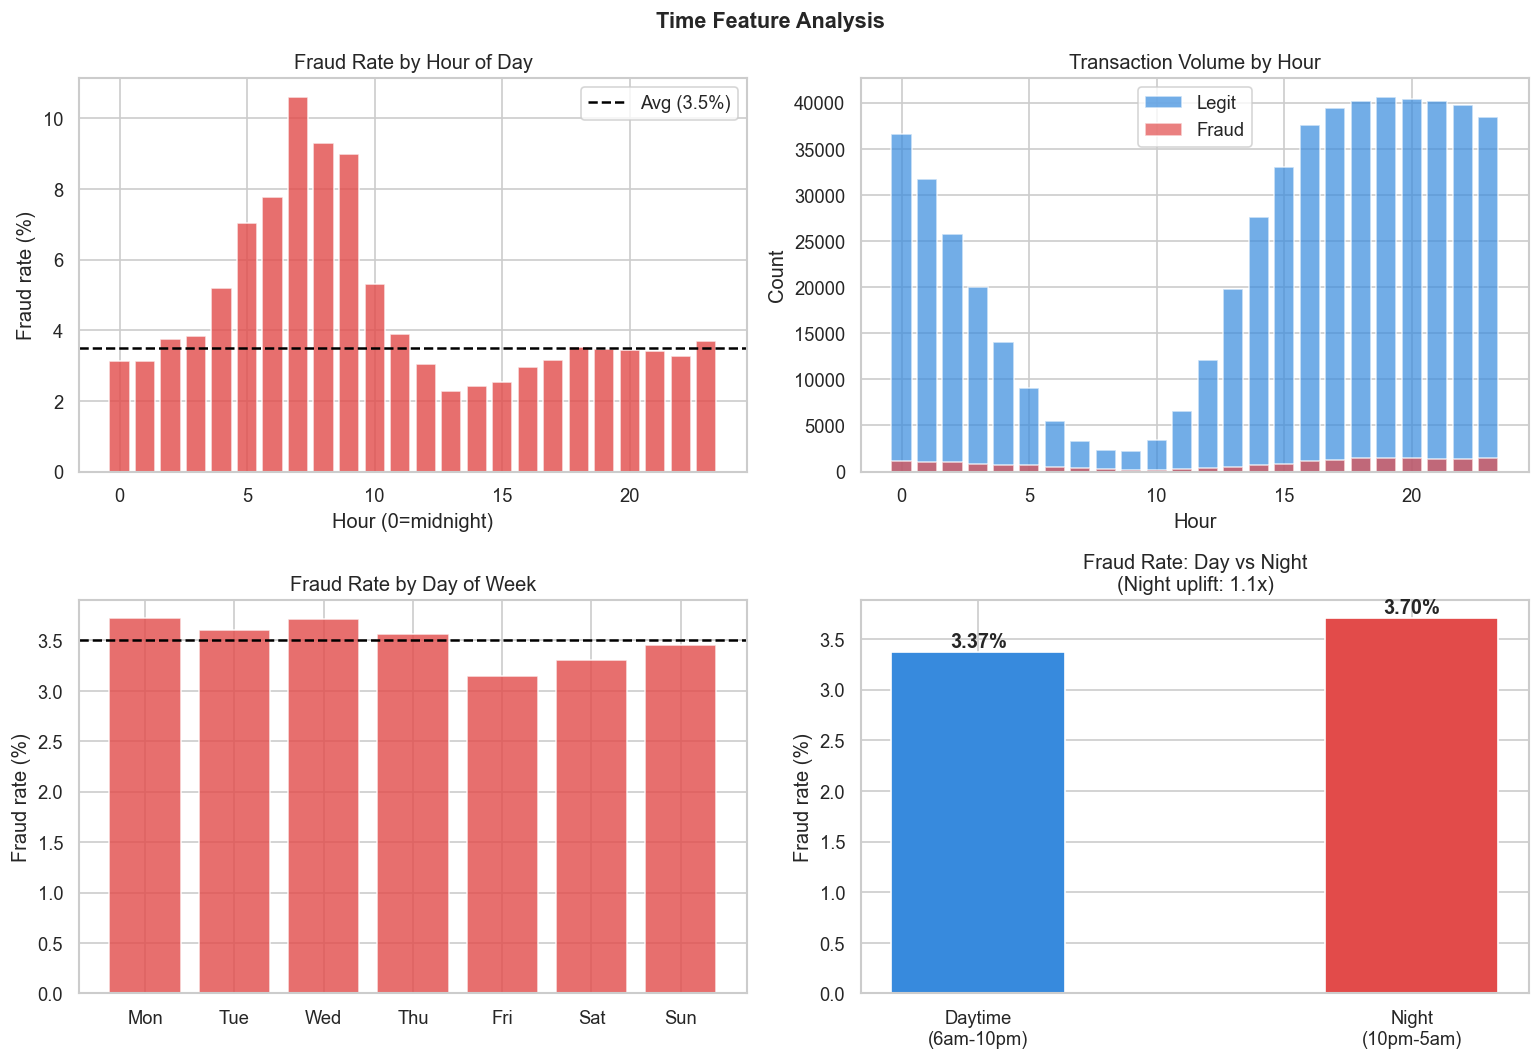


Night fraud rate  : 3.70%
Day fraud rate    : 3.37%
Night uplift      : 1.10x


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Fraud rate by hour
fraud_by_hour = df.groupby('hour')['isFraud'].mean() * 100
axes[0,0].bar(fraud_by_hour.index, fraud_by_hour.values, color='#E24B4A', alpha=0.8)
axes[0,0].axhline(y=fraud_rate*100, color='black', linestyle='--',
                  label=f'Avg ({fraud_rate*100:.1f}%)')
axes[0,0].set_title('Fraud Rate by Hour of Day')
axes[0,0].set_xlabel('Hour (0=midnight)')
axes[0,0].set_ylabel('Fraud rate (%)')
axes[0,0].legend()

# Transaction volume by hour
vol_legit = df[df['isFraud']==0].groupby('hour').size()
vol_fraud = df[df['isFraud']==1].groupby('hour').size()
axes[0,1].bar(vol_legit.index, vol_legit.values, color='#378ADD', alpha=0.7, label='Legit')
axes[0,1].bar(vol_fraud.index, vol_fraud.values, color='#E24B4A', alpha=0.7, label='Fraud', bottom=0)
axes[0,1].set_title('Transaction Volume by Hour')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Fraud rate by day of week
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fraud_by_dow = df.groupby('day_of_week')['isFraud'].mean() * 100
axes[1,0].bar(days[:len(fraud_by_dow)], fraud_by_dow.values, color='#E24B4A', alpha=0.8)
axes[1,0].axhline(y=fraud_rate*100, color='black', linestyle='--')
axes[1,0].set_title('Fraud Rate by Day of Week')
axes[1,0].set_ylabel('Fraud rate (%)')

# Night vs day fraud rate
night_fraud = df.groupby('is_night')['isFraud'].mean() * 100
night_uplift = night_fraud[1] / night_fraud[0]
axes[1,1].bar(['Daytime\n(6am-10pm)', 'Night\n(10pm-5am)'],
              night_fraud.values, color=['#378ADD','#E24B4A'], width=0.4)
axes[1,1].set_title(f'Fraud Rate: Day vs Night\n(Night uplift: {night_uplift:.1f}x)')
axes[1,1].set_ylabel('Fraud rate (%)')
for i, v in enumerate(night_fraud.values):
    axes[1,1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Time Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_03_time_features.png', bbox_inches='tight')
plt.show()

print(f'\nNight fraud rate  : {night_fraud[1]:.2f}%')
print(f'Day fraud rate    : {night_fraud[0]:.2f}%')
print(f'Night uplift      : {night_uplift:.2f}x')

In [10]:
# Weekend analysis
weekend_fraud = df.groupby('is_weekend')['isFraud'].mean() * 100
print('Fraud rate by weekend:')
print(f'  Weekday : {weekend_fraud[0]:.2f}%')
print(f'  Weekend : {weekend_fraud[1]:.2f}%')

# Clean up
df.drop(columns=['hour','day_of_week','is_night','is_weekend','amt_decimal'], inplace=True)

Fraud rate by weekend:
  Weekday : 3.55%
  Weekend : 3.38%


**→ Preprocessing decision:**  
- `TransactionDT` is seconds since a reference point — extract `hour` and `day_of_week`  
- Night hours (10pm–5am) show elevated fraud rate — create binary `is_night` flag  
- `is_weekend` carries mild signal — include as binary feature  
- Drop raw `TransactionDT` after feature extraction — raw seconds have no direct meaning to the model